# SA vs SAT Transpilation Comparison

This notebook benchmarks two QAOA circuit transpilation strategies — **Simulated Annealing (SA)** and **SAT-based mapping (SAT)** — across different graph densities and time budgets, measuring the resulting 2-qubit gate count and circuit depth on a 1D-chain backend.

In [1]:
from qiskit import transpile
from qiskit.circuit import ParameterVector, ClassicalRegister
from PTC_utils import PTC_pairs
from SWAP_utils import SWAP_pairs, qaoa_SWAP
from utils import total_cnots_depth
from copy import copy
from simulated_annealing import simulated_annealing_func
import json
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import time

import utils
from qiskit.providers.fake_provider import GenericBackendV2


## Backend Setup

Define a synthetic 1D-chain backend using `GenericBackendV2`. All experiments run on this ideal topology to isolate the effect of transpilation strategy.

In [2]:
# Custom ideal 1D-chain backend
def make_1d_backend(num_qubits, basis_gates=None, seed=42):
    """Return a GenericBackendV2 with a 1D chain coupling map."""
    if basis_gates is None:
        basis_gates = ["x", "cx", "sx", "rz", "id", "rzz", "rx"]
    coupling_map = [[i, i + 1] for i in range(num_qubits - 1)] + \
                   [[i + 1, i] for i in range(num_qubits - 1)]
    return GenericBackendV2(
        num_qubits=num_qubits,
        basis_gates=basis_gates,
        coupling_map=coupling_map,
        seed=seed,
    )

backends = {}
backends["1d_chain"] = make_1d_backend(500)

## SA Helper: `method_SA`

Runs simulated annealing to find an optimal qubit mapping for a given problem graph. Returns the best mapping and the list of 2-qubit gate slots used by the SWAP-based circuit.

In [3]:
def method_SA(G, method, callback, max_iter_sa = 5, initial_temp=0.01, cooling_rate=0.999, stop_temp=1e-8, max_iter=10000, verbose=False, best_map=None, max_reheat=5):
    nq = G.number_of_nodes()
    if method == "PTC":
        list_2q = PTC_pairs(nq)
    elif method == "SWAP":
        list_2q = SWAP_pairs(nq)
    else:
        raise TypeError("Method not in list of methods")
    best_cost = 0
    
    if best_map is None:
        global_best = dict(zip(range(nq), range(nq)))
        best_map = dict(zip(range(nq), range(nq)))
    else:
        global_best = copy(best_map)
        best_map = {v: k for k, v in best_map.items()}
        print("here")
    for _ in range(max_iter_sa):
        best_map, current_cost, _ = simulated_annealing_func(G, best_map, list_2q, callback, initial_temp=initial_temp, cooling_rate=cooling_rate, stop_temp=stop_temp, max_iter=max_iter, verbose=verbose, max_reheat=max_reheat)
        if current_cost < best_cost:
            best_cost = current_cost
            global_best = copy(best_map)
        else:
            break
    mapping = {v: k for k, v in global_best.items()}
    G_shuffled = nx.relabel_nodes(G.copy(), mapping)
    _ , depth = total_cnots_depth(G_shuffled, list_2q)
    print("depth:", depth)
    list_used = copy(list_2q[:nq+depth])
    return mapping, list_used

## Time-Budget Sweep

Sweeps over SA iteration counts and SAT solver timeouts for several Erdős–Rényi graph densities (`Ed`). Records wall-clock time, 2-qubit gate count, circuit depth, and total operation count after transpilation.

In [7]:
seed = 1
nq = 200
p = 10

eds = [0.1]
backend_name = "1d_chain"
method = "SWAP"
backend = backends[backend_name]
skip_gates = {"measure", "barrier"}

sa_iters   = [int(1e3), int(1e4), int(1e5), int(2e5), int(5e5), int(10e5)]
# sa_iters = []
sat_timeouts = [0.1, 1, 2, 5, 10, 60]
# sat_timeouts = []

sa_time_results  = {}
sat_time_results = {}

for Ed_i in eds:
    print(f"\n{'='*60}")
    print(f"Ed = {Ed_i}")
    print(f"{'='*60}")
    G_ed = nx.erdos_renyi_graph(nq, Ed_i, seed=seed)
    while nx.is_connected(G_ed) == False:
        G_ed = nx.erdos_renyi_graph(nq, Ed_i)
    for i, j in G_ed.edges():
        G_ed[i][j]["weight"] = 1
    

    sa_time_results[Ed_i]  = {"max_iter": [], "time": [], "2q_gates": [], "depth": [], "total_ops": []}
    sat_time_results[Ed_i] = {"timeout":  [], "time": [], "2q_gates": [], "depth": [], "total_ops": []}

    # ------------------------------------------------------------------ SA sweep
    print("  SA sweep:")
    for max_iter in sa_iters:
        callback_sa = {"cost": [], "depth": [], "iterations": [], "T": [], "cost_cache": {}}
        ti = time.time()
        mapping_sa, list_used_sa = method_SA(
            G_ed.copy(), method, callback_sa,
            initial_temp=0.01, cooling_rate=0.999, max_iter_sa=1,
            max_iter=max_iter, verbose=False, max_reheat=5)
        sa_time = time.time() - ti

        G_shuffled_sa = nx.relabel_nodes(G_ed.copy(), mapping_sa)
        betas_pv  = ParameterVector("betas",  p)
        gammas_pv = ParameterVector("gammas", p)
        qc_sa = qaoa_SWAP(gammas_pv, betas_pv, G_shuffled_sa, list_used_sa)
        qc_sa.add_register(ClassicalRegister(nq))
        qc_sa.measure(reversed(range(nq)), range(nq))
        circ_sa = transpile(qc_sa, backend, optimization_level=1)

        sa_ops      = circ_sa.count_ops()
        sa_2q       = sum(v for k, v in sa_ops.items() if k in ["cx", "cz", "ecr", "rzz"])
        sa_depth_val = circ_sa.depth(lambda x: len(x.qubits) == 2)
        sa_total    = sum(v for k, v in sa_ops.items() if k not in skip_gates)

        sa_time_results[Ed_i]["max_iter"].append(max_iter)
        sa_time_results[Ed_i]["time"].append(sa_time)
        sa_time_results[Ed_i]["2q_gates"].append(sa_2q)
        sa_time_results[Ed_i]["depth"].append(sa_depth_val)
        sa_time_results[Ed_i]["total_ops"].append(sa_total)

        print(f"    max_iter={max_iter:.0e} | time={sa_time:.2f}s | 2q={sa_2q} | depth={sa_depth_val}")

    # ------------------------------------------------------------------ SAT sweep
    print("  SAT sweep:")
    for timeout in sat_timeouts:
        graph_sat = G_ed.copy()
        ti = time.time()
        try:
            qc_sat, _ = utils.make_qaoa_circuit(graph_sat, reps=p, backend=backend, sat_timeout=timeout)
            sat_time = time.time() - ti
            circ_sat = transpile(qc_sat, backend, optimization_level=2)
            sat_ops       = circ_sat.count_ops()
            sat_2q        = sum(v for k, v in sat_ops.items() if k in ["cx", "cz", "ecr", "rzz"])
            sat_depth_val = circ_sat.depth(lambda x: len(x.qubits) == 2)
            sat_total     = sum(v for k, v in sat_ops.items() if k not in skip_gates)
            print(f"    timeout={timeout}s | time={sat_time:.2f}s | 2q={sat_2q} | depth={sat_depth_val}")
        except:
            sat_time      = time.time() - ti
            sat_2q        = float("nan")
            sat_depth_val = float("nan")
            sat_total     = float("nan")
            print(f"    timeout={timeout}s | SAT found no solution — recording nan")

        sat_time_results[Ed_i]["timeout"].append(timeout)
        sat_time_results[Ed_i]["time"].append(sat_time)
        sat_time_results[Ed_i]["2q_gates"].append(sat_2q)
        sat_time_results[Ed_i]["depth"].append(sat_depth_val)
        sat_time_results[Ed_i]["total_ops"].append(sat_total)

print("\nTime-budget sweep done!")



Ed = 0.1
Is connected: True
  SA sweep:
depth: -8
    max_iter=1e+03 | time=0.44s | 2q=567280 | depth=5720
depth: -20
    max_iter=1e+04 | time=4.41s | 2q=531470 | depth=5360
depth: -22
    max_iter=1e+05 | time=3.42s | 2q=525500 | depth=5300
depth: -20
    max_iter=2e+05 | time=7.61s | 2q=531440 | depth=5360
depth: -21
    max_iter=5e+05 | time=3.50s | 2q=528480 | depth=5330
depth: -20
    max_iter=1e+06 | time=3.45s | 2q=531470 | depth=5360
  SAT sweep:
    timeout=0.1s | SAT found no solution — recording nan
    timeout=1s | SAT found no solution — recording nan
    timeout=2s | SAT found no solution — recording nan
    timeout=5s | time=894.68s | 2q=522040 | depth=5320
    timeout=10s | time=940.15s | 2q=525590 | depth=5350
    timeout=60s | time=1332.03s | 2q=513290 | depth=5230

Time-budget sweep done!


## Save Results

Serializes the sweep results to a JSON file for later analysis or plotting.

In [ ]:
def _to_serializable(obj):
    """Recursively convert numpy scalars / arrays to plain Python types."""
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_serializable(i) for i in obj]
    if hasattr(obj, "item"):          # numpy scalar
        return obj.item()
    return obj

summary = {
    "meta": {
        "nq": nq,
        "p": p,
        "seed": seed,
        "backend": backend_name,
        "sa_max_iters": sa_iters,
        "sat_timeouts": sat_timeouts,
    },
    "SA":  _to_serializable(sa_time_results),
    "SAT": _to_serializable(sat_time_results),
}

out_path = f"./Data/time_sweep_nq{nq}_p{p}_seed{seed}.json"
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Saved to {out_path}")


Saved to ./Data/time_sweep_nq20_p10_seed1.json


## Plot: 2-Qubit Gate Count vs Wall-Clock Time

Loads saved results and plots SA vs SAT performance across graph densities. Each curve shows how the 2-qubit gate count changes as more time is given to the solver.

Ed=0.05:  
SA: [0.8835577964782715, 2.120213031768799, 16.411319732666016, 16.470365047454834, 89.4492518901825, 98.36833214759827]
SAT: [381.8820400238037, 402.779972076416, 516.4409122467041, 471.1547119617462, 1066.1710829734802, 1143.5083708763123]
Ed=0.1:  
SA: [0.286344051361084, 1.9212610721588135, 10.49549388885498, 30.761438369750977, 96.40217018127441, 125.71659898757935]
SAT: [579.4690289497375, 591.2283091545105, 803.9950699806213, 874.1455068588257, 842.8257138729095, 955.1994388103485]
Ed=0.2:  
SA: [0.3437228202819824, 1.7234339714050293, 17.071382999420166, 57.3866810798645, 105.14659881591797, 145.16354203224182]
SAT: [908.1415138244629, 896.2755980491638, 913.089378118515, 1102.5680940151215, 1132.3557131290436, 1428.0494248867035]
Ed=0.4:  
SA: [0.43671488761901855, 3.5795540809631348, 21.097524881362915, 28.18617606163025, 71.09611487388611, 177.52346801757812]
SAT: [3450.5781631469727, 3080.9349110126495, 3635.5673308372498, 3354.801023006439, 3363.6840698719025, 4

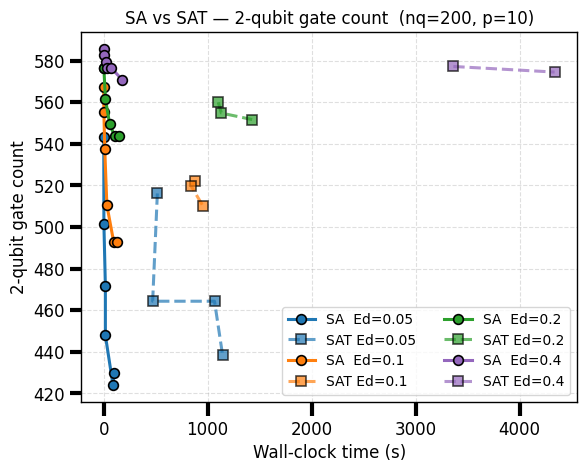

In [9]:
nq = 200
p = 10
seed = 1
out_path = f"./Data/time_sweep_nq{nq}_p{p}_seed{seed}.json"

with open(out_path, "r") as f:
    loaded_summary = json.load(f)

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

eds = [float(k) for k in loaded_summary["SA"].keys()]
sa_time_results_loaded  = {float(k): v for k, v in loaded_summary["SA"].items()}
sat_time_results_loaded = {float(k): v for k, v in loaded_summary["SAT"].items()}

ed_labels = [f"Ed={round(e, 3)}" for e in eds]
colors = cm.tab10(np.linspace(0, 0.4, len(eds)))

fig, axes = plt.subplots()

for ax, metric, ylabel in zip(
        [axes],
        ["2q_gates"],
        ["2-qubit gate count"]):

    for idx, Ed_i in enumerate(eds):
        color = colors[idx]
        label = ed_labels[idx]

        sa  = sa_time_results_loaded[Ed_i]
        sat = sat_time_results_loaded[Ed_i]

        ax.plot(sa["time"],  np.array(sa[metric])/1000,
                "o-",  color=color, label=f"SA  {label}", markeredgecolor="black", markersize=7)
        ax.plot(sat["time"], np.array(sat[metric])/1000,
                "s--", color=color, label=f"SAT {label}", markeredgecolor="black", markersize=7, alpha=0.7)
        print(f"Ed={Ed_i}:  ")
        print("SA:", sa["time"])
        print("SAT:", sat["time"])
    ax.set_xlabel("Wall-clock time (s)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"SA vs SAT — {ylabel}  (nq={nq}, p={p})")
    ax.legend(fontsize=10, ncol=2)
    ax.grid(True, linestyle="--", alpha=0.4)
fig.savefig(f"./Data/time_sweep_nq{nq}_p{p}_seed{seed}_2q_gates.pdf", transparent=True, bbox_inches="tight")

